In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Food_Delivery_Times.csv')

In [ ]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.isna().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


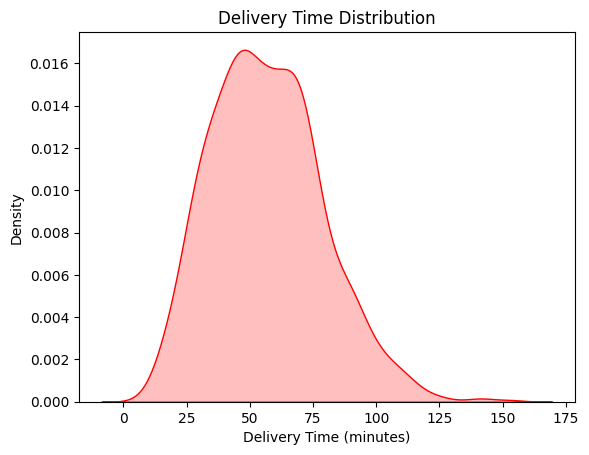

In [ ]:
sns.kdeplot(df['Delivery_Time_min'], color='red',fill=True)
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Density')
plt.show()

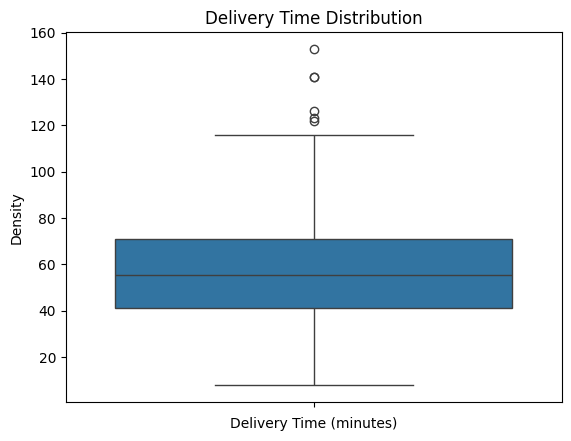

In [ ]:
sns.boxplot(df['Delivery_Time_min'])
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Density')
plt.show()

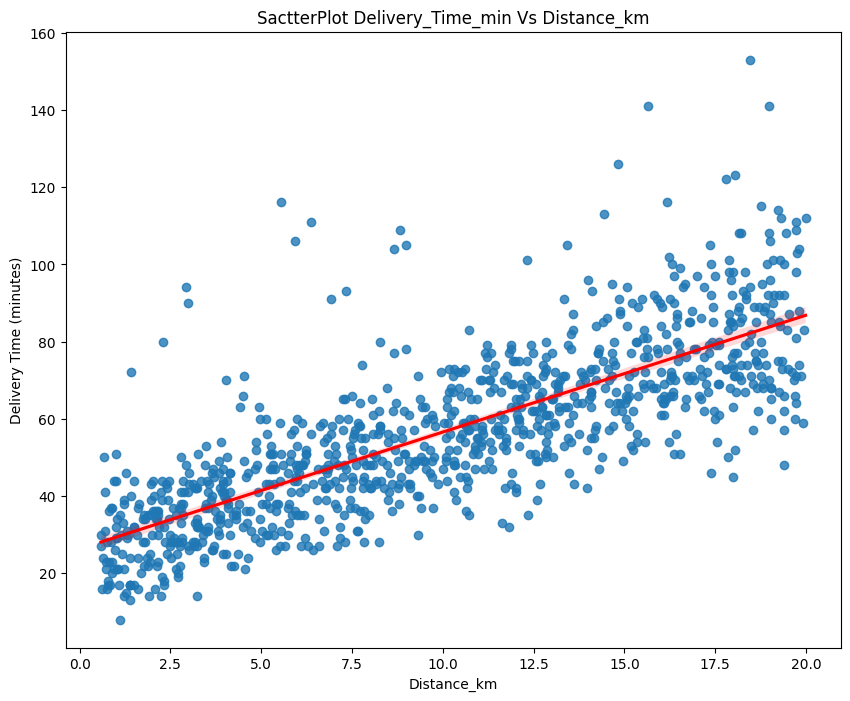

In [ ]:
plt.figure(figsize=(10, 8))
sns.regplot(x='Distance_km', y='Delivery_Time_min', data=df, line_kws={"color":"red"})
plt.title('SactterPlot Delivery_Time_min Vs Distance_km')
plt.xlabel('Distance_km')
plt.ylabel('Delivery Time (minutes)')
plt.show()

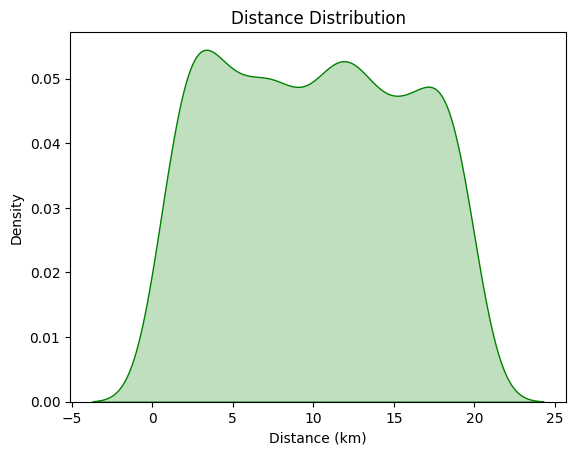

In [ ]:
sns.kdeplot(df['Distance_km'], color='green', fill=True)
plt.title('Distance Distribution')
plt.xlabel('Distance (km)')
plt.ylabel('Density')
plt.show()

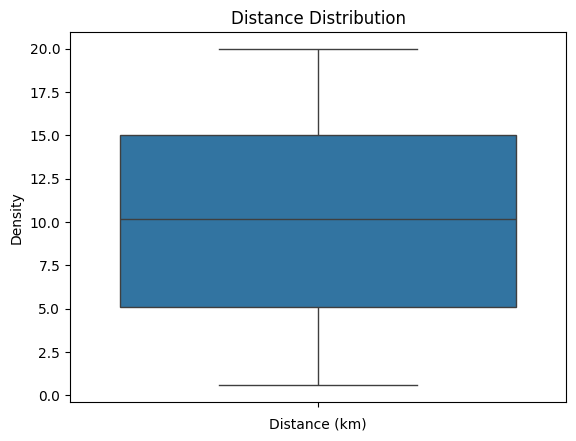

In [ ]:
sns.boxplot(df['Distance_km'])
plt.title('Distance Distribution')
plt.xlabel('Distance (km)')
plt.ylabel('Density')
plt.show()

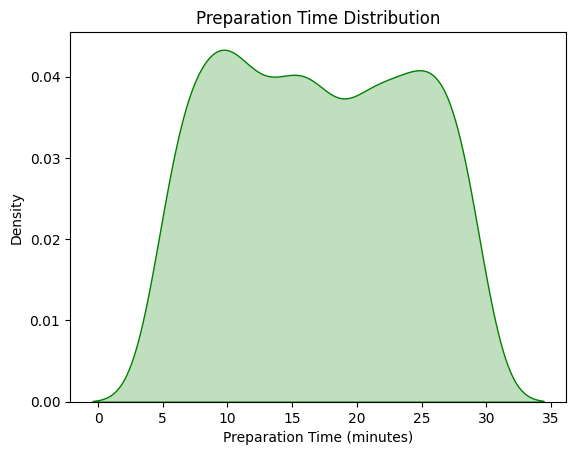

In [ ]:
sns.kdeplot(df['Preparation_Time_min'], color='green', fill=True)
plt.title('Preparation Time Distribution')
plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Density')
plt.show()

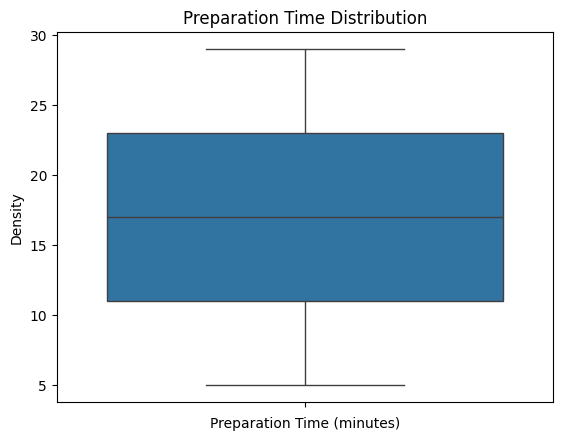

In [ ]:
sns.boxplot(df['Preparation_Time_min'])
plt.title('Preparation Time Distribution')
plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Density')
plt.show()

In [ ]:
numeric_cols = ['Delivery_Time_min', 'Distance_km', 'Preparation_Time_min']

for col in numeric_cols:
  skewness = df[col].skew()
  print(f'Skewness of {col}: {skewness}')

Skewness of Delivery_Time_min: 0.5072511816152696
Skewness of Distance_km: 0.038840474919290116
Skewness of Preparation_Time_min: 0.030008161330597263


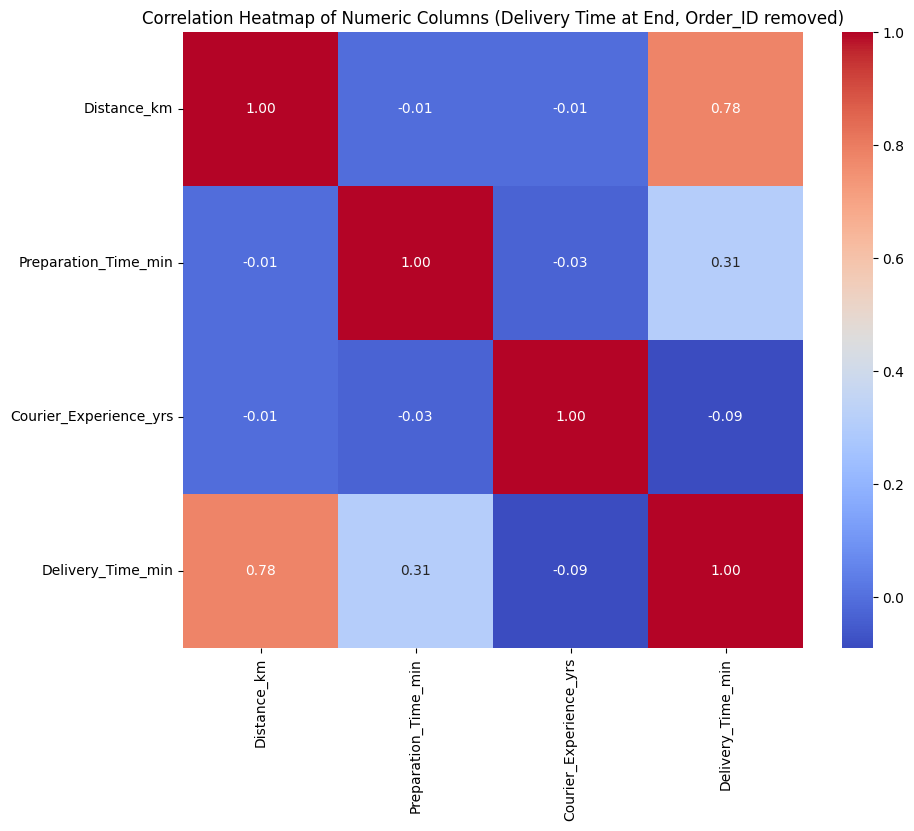

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

# Remove 'Order_ID' column as it's not relevant for correlation analysis
if 'Order_ID' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['Order_ID'])

# Define the target column
target_column = 'Delivery_Time_min'

# Get all columns except the target
other_columns = [col for col in numeric_df.columns if col != target_column]

# Reorder columns to place target at the end
ordered_columns = other_columns + [target_column]
numeric_df_ordered = numeric_df[ordered_columns]

correlation_matrix = numeric_df_ordered.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Columns (Delivery Time at End, Order_ID removed)')
plt.show()

In [ ]:
cate_cols = df.select_dtypes('object').columns.tolist()
cate_cols.append('Courier_Experience_yrs')
cate_cols

['Weather',
 'Traffic_Level',
 'Time_of_Day',
 'Vehicle_Type',
 'Courier_Experience_yrs']

/tmp/ipykernel_2159/2192798618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


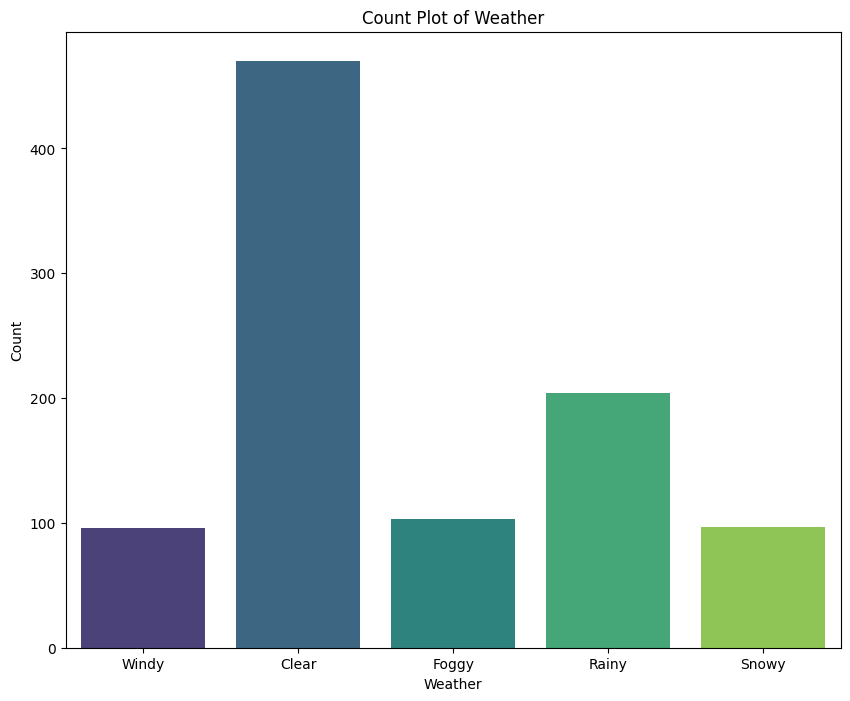

/tmp/ipykernel_2159/2192798618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


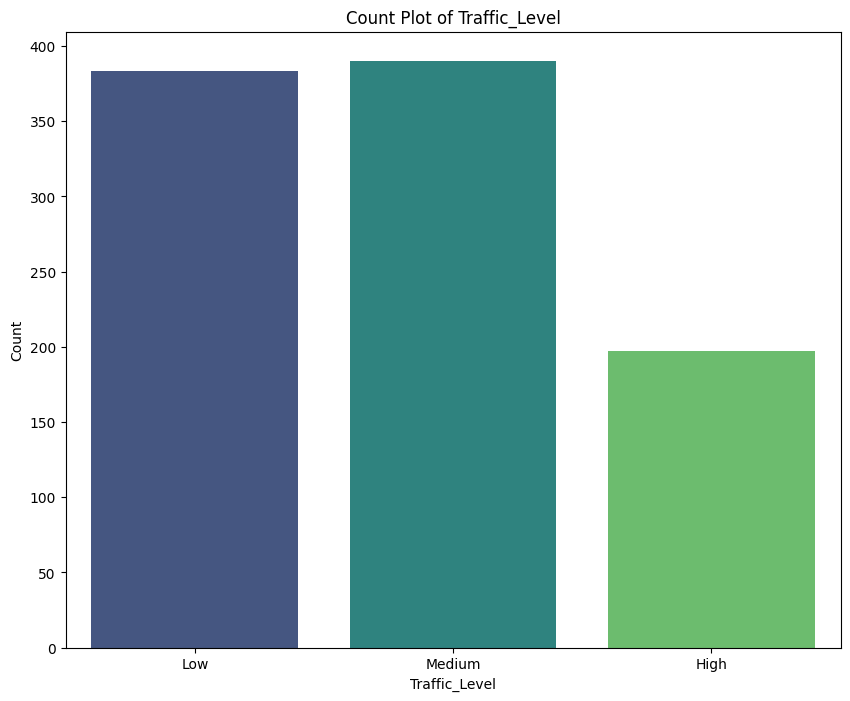

/tmp/ipykernel_2159/2192798618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


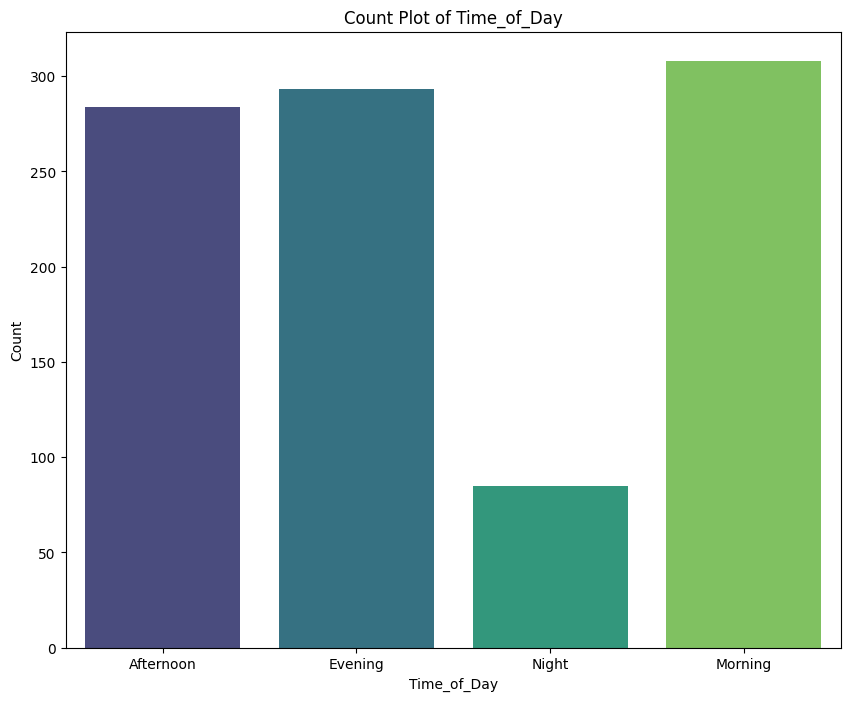

/tmp/ipykernel_2159/2192798618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


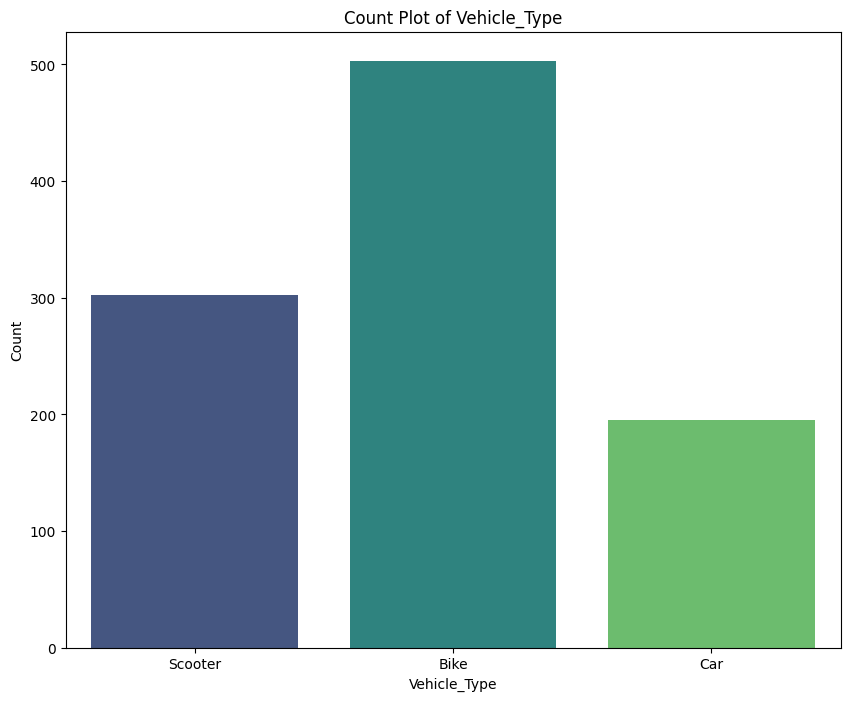

/tmp/ipykernel_2159/2192798618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


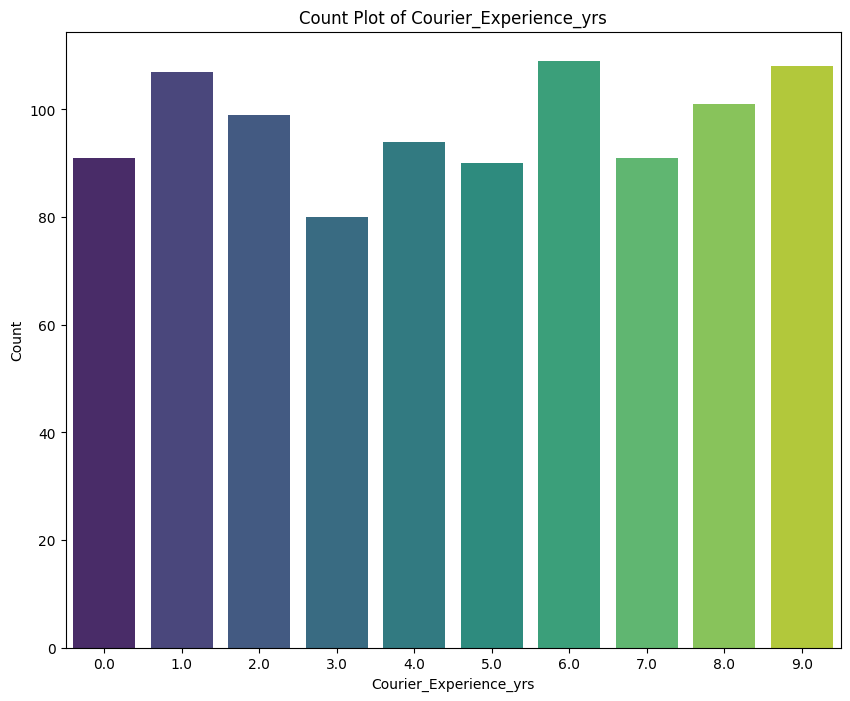

In [ ]:
for col in cate_cols:
  plt.figure(figsize=(10,8))
  sns.countplot(x=df[col], palette='viridis')
  plt.title(f'Count Plot of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.show()

/tmp/ipykernel_2159/4109441510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Delivery_Time_min'], palette='viridis')


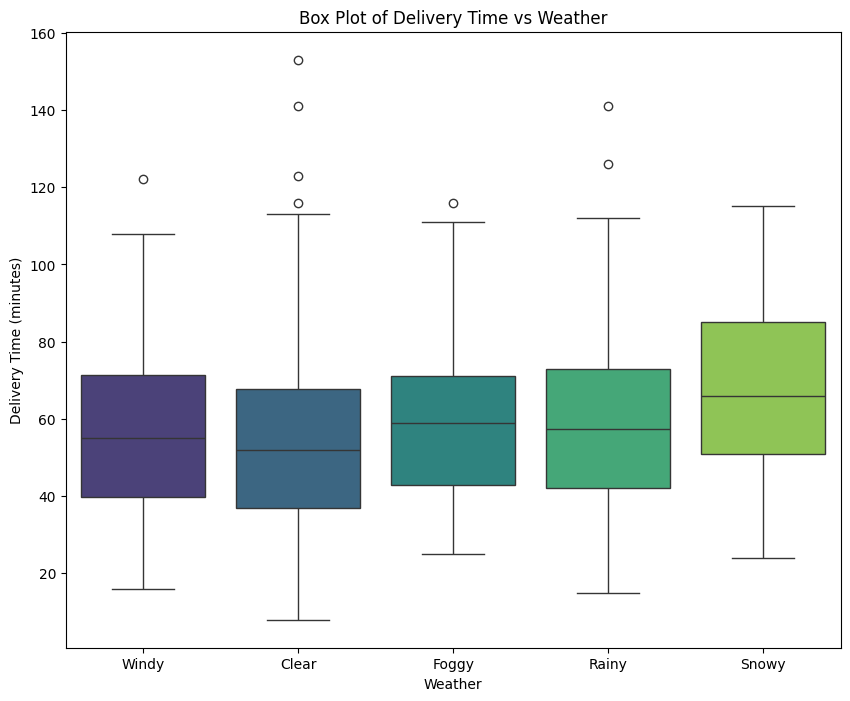

/tmp/ipykernel_2159/4109441510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Delivery_Time_min'], palette='viridis')


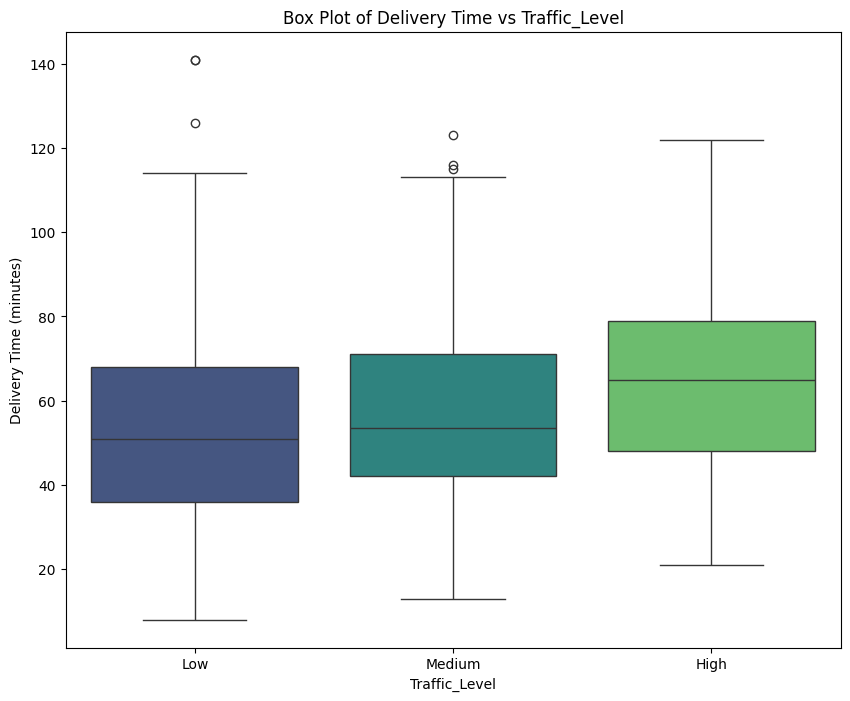

/tmp/ipykernel_2159/4109441510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Delivery_Time_min'], palette='viridis')


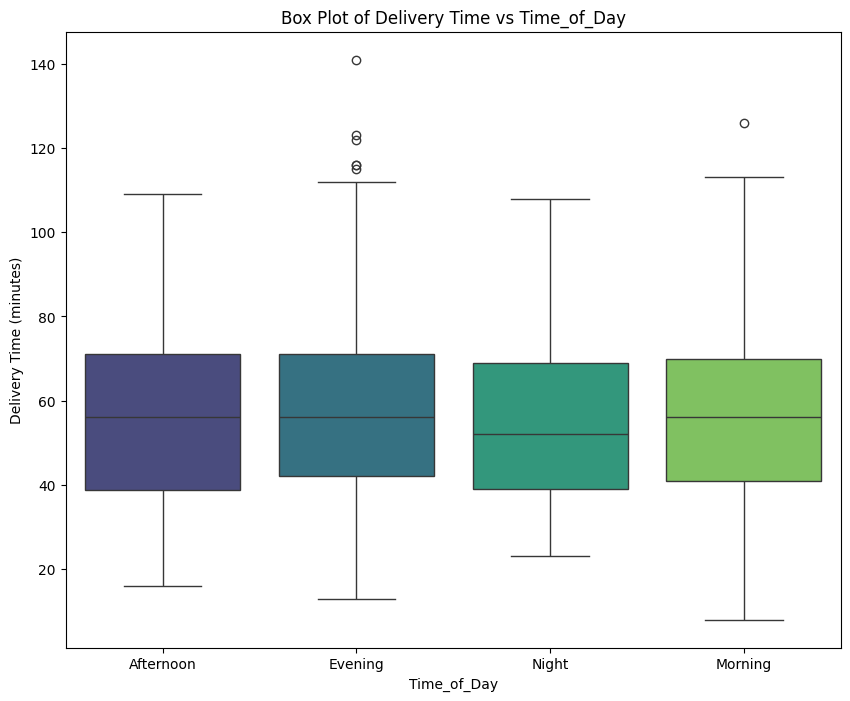

/tmp/ipykernel_2159/4109441510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Delivery_Time_min'], palette='viridis')


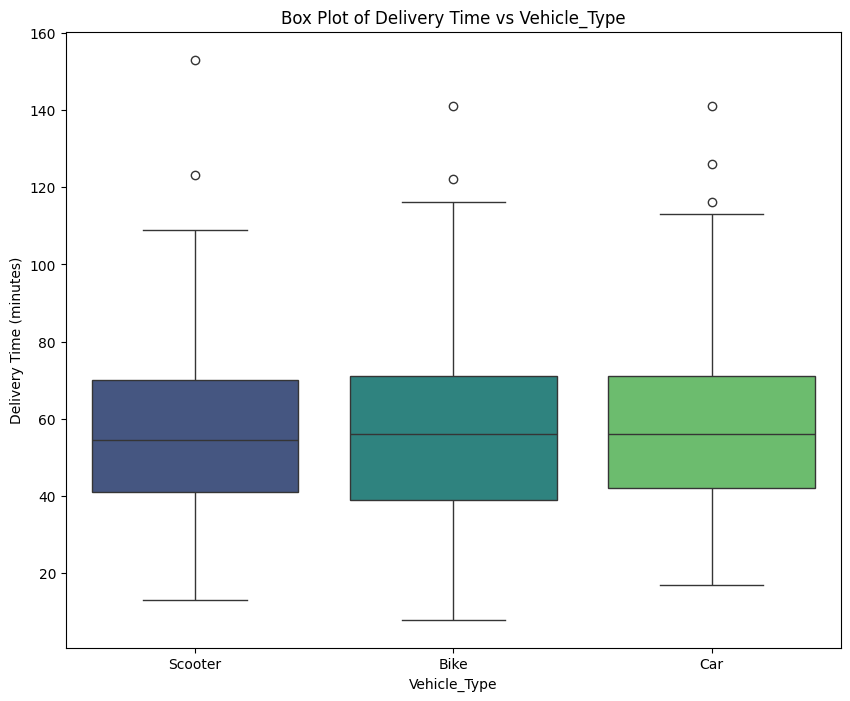

/tmp/ipykernel_2159/4109441510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Delivery_Time_min'], palette='viridis')


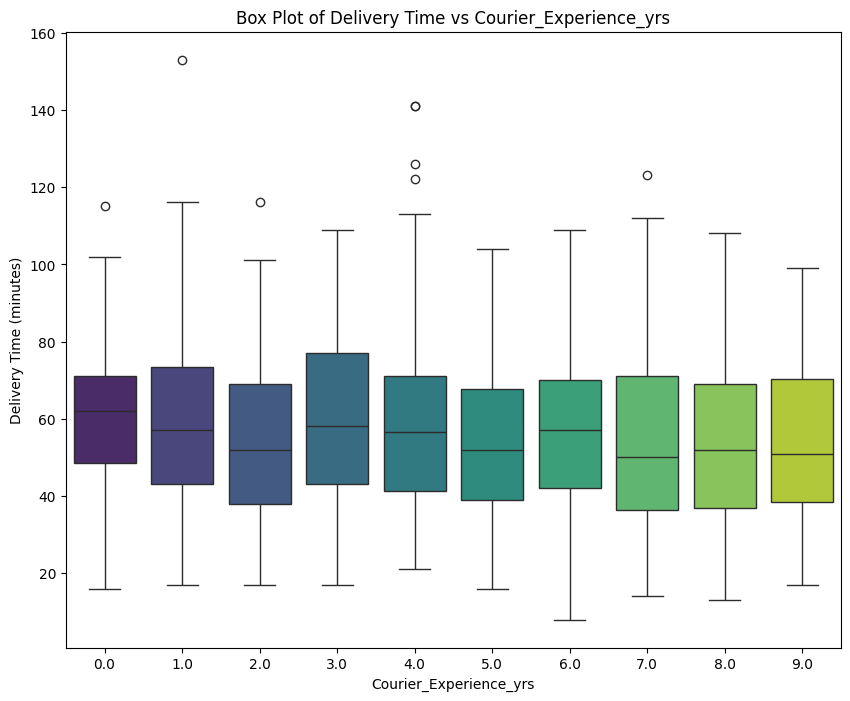

In [ ]:
for col in cate_cols:
  plt.figure(figsize=(10,8))
  sns.boxplot(x=df[col], y=df['Delivery_Time_min'], palette='viridis')
  plt.title(f'Box Plot of Delivery Time vs {col}')
  plt.xlabel(col)
  plt.ylabel('Delivery Time (minutes)')
  plt.show()

In [ ]:
from scipy.stats import f_oneway

for col in cate_cols:
    # Drop rows where the categorical column or Delivery_Time_min is NaN
    temp_df = df.dropna(subset=[col, 'Delivery_Time_min'])

    # Get unique categories and filter out any NaN if present
    categories = temp_df[col].unique()
    categories = [cat for cat in categories if pd.notna(cat)]

    if len(categories) < 2: # ANOVA requires at least two groups
        print(f"Skipping ANOVA for '{col}': Less than two valid categories found.")
        continue

    # Create a list of 'Delivery_Time_min' values for each category
    groups = [temp_df['Delivery_Time_min'][temp_df[col] == cat] for cat in categories]

    # Perform one-way ANOVA test
    f_statistic, p_value = f_oneway(*groups)

    print(f"\nANOVA for '{col}' and 'Delivery_Time_min':")
    print(f"F-statistic: {f_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    # Determine significance (common alpha level is 0.05)
    alpha = 0.05
    if p_value < alpha:
        print("Conclusion: There is a significant difference in Delivery_Time_min across different groups of " + col)
    else:
        print("Conclusion: There is no significant difference in Delivery_Time_min across different groups of " + col)



ANOVA for 'Weather' and 'Delivery_Time_min':
F-statistic: 10.4565
P-value: 0.0000
Conclusion: There is a significant difference in Delivery_Time_min across different groups of Weather

ANOVA for 'Traffic_Level' and 'Delivery_Time_min':
F-statistic: 20.1671
P-value: 0.0000
Conclusion: There is a significant difference in Delivery_Time_min across different groups of Traffic_Level

ANOVA for 'Time_of_Day' and 'Delivery_Time_min':
F-statistic: 0.3674
P-value: 0.7765
Conclusion: There is no significant difference in Delivery_Time_min across different groups of Time_of_Day

ANOVA for 'Vehicle_Type' and 'Delivery_Time_min':
F-statistic: 0.5894
P-value: 0.5549
Conclusion: There is no significant difference in Delivery_Time_min across different groups of Vehicle_Type

ANOVA for 'Courier_Experience_yrs' and 'Delivery_Time_min':
F-statistic: 1.7517
P-value: 0.0735
Conclusion: There is no significant difference in Delivery_Time_min across different groups of Courier_Experience_yrs
